Canonical Correlation Analysis 

In [1]:
import os
import pandas as pd
import numpy as np

from neurostatx.io.loader import DatasetLoader
from sklearn.impute import KNNImputer  
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

ModuleNotFoundError: No module named 'pandas'

In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
data_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/data/"
ping_cfa_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/preprocessing/PING_CFA_Apply/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Load ping data
ping_cfa = pd.read_excel(f"{ping_cfa_dir}/transformed_dataset.xlsx")

# Load bundles
bundles = pd.read_csv(f"{data_dir}/bundles_mean_stats.tsv", sep='\t')

In [5]:
# Enlever sub- dans la colonne sample du dataset bundles pour faciliter la fusion avec le dataset ping_cfa
bundles['sample'] = bundles['sample'].str.replace('sub-', '', regex=False)

# Convertir en string des deux côtés pour éviter les faux mismatch
ping_cfa["Sample"] = ping_cfa["Sample"].astype(str)
bundles["sample"] = bundles["sample"].astype(str) 

# Filter le dataset ping_cfa pour ne garder que les individus présents dans le dataset bundles
ping_cfa_filtered = ping_cfa[ping_cfa['Sample'].isin(bundles['sample'])].copy()

# Filter le sataset bundles pour ne garder que les individus présents dans le dataset ping_cfa
bundles_filtered = bundles[bundles['sample'].isin(ping_cfa['Sample'])].copy()

ping_cfa_filtered.to_excel(f"{output_dir}/ping_data_filtered_for_bundles.xlsx", index=False, header=True)
bundles_filtered.to_excel(f"{output_dir}/bundles_data_filtered_for_ping.xlsx", index=False, header=True)


On test d'abord le CCA avec les données de fractional anisotropy seulement pour chaque faisceaux

In [15]:
# Reshape the bundles dataset to have one row per sample and one column per bundle, with the values being the FA
bundles_fa = bundles_filtered.pivot(
    index="sample",
    columns="bundle",
    values="fa"
).reset_index()

# Find the common samples between the two datasets
common = set(ping_cfa_filtered["Sample"]).intersection(bundles_fa["sample"])

brain = bundles_fa[bundles_fa["sample"].isin(common)].sort_values("sample")
cog = ping_cfa_filtered[ping_cfa_filtered["Sample"].isin(common)].sort_values("Sample")

# Verifier l'ordre des samples
(brain["sample"].values == cog["Sample"].values).all()

True

In [43]:
# Contruire les matrices X et Y 
cog_vars = ["VA", "EFPS", "MEM"]

X = brain.copy()
Y = cog[cog_vars]
Y.index = cog["Sample"]

# Il faut dabord supprimer les faisceaux qui ont trop de valeurs manquantes (> 20% de valeurs manquantes)
missing_ratio = X.drop(columns="sample").isna().mean()

cols_keep = missing_ratio[missing_ratio < 0.2].index

X = X[['sample'] + list(cols_keep)]
X = X.set_index("sample")


In [ ]:
# Methode KNN pour imputer les valeurs manquantes

fa_data = X.copy()

# Create a loop that test out various K values for the KNN imputer
k_values = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400]
results = []

rng = np.random.default_rng(42)

for k in k_values:
    KNN_partial = KNNImputer(n_neighbors=k, weights="distance",
                             metric="nan_euclidean", keep_empty_features=True)
    KNN_partial.fit(fa_data)

    dict_imputed = {'k': k}
    for var in fa_data.columns:
        oneout = fa_data.copy()
        observed_idx = oneout.index[oneout[var].notna()]
        if len(observed_idx) < 5:
            dict_imputed[var] = np.nan
            continue

        mask = max(2, int(len(observed_idx) * 0.2))
        masked_idx = rng.choice(observed_idx, size=mask, replace=False)
        
        oneout.loc[masked_idx, var] = np.nan

        imputed = pd.DataFrame(KNN_partial.transform(oneout), columns=oneout.columns, index=oneout.index)

        true_values = fa_data.loc[masked_idx, var]
        imputed_values = imputed.loc[masked_idx, var]

        mae = mean_absolute_error(true_values, imputed_values)
        rmse = np.sqrt(mean_squared_error(true_values, imputed_values))

        dict_imputed[var] = rmse
    dict_imputed['mean_rmse'] = np.nanmean([v for key, v in dict_imputed.items() if key not in ["k", "mean_rmse"]])  

    results.append(dict_imputed)

results_df = pd.DataFrame(results)

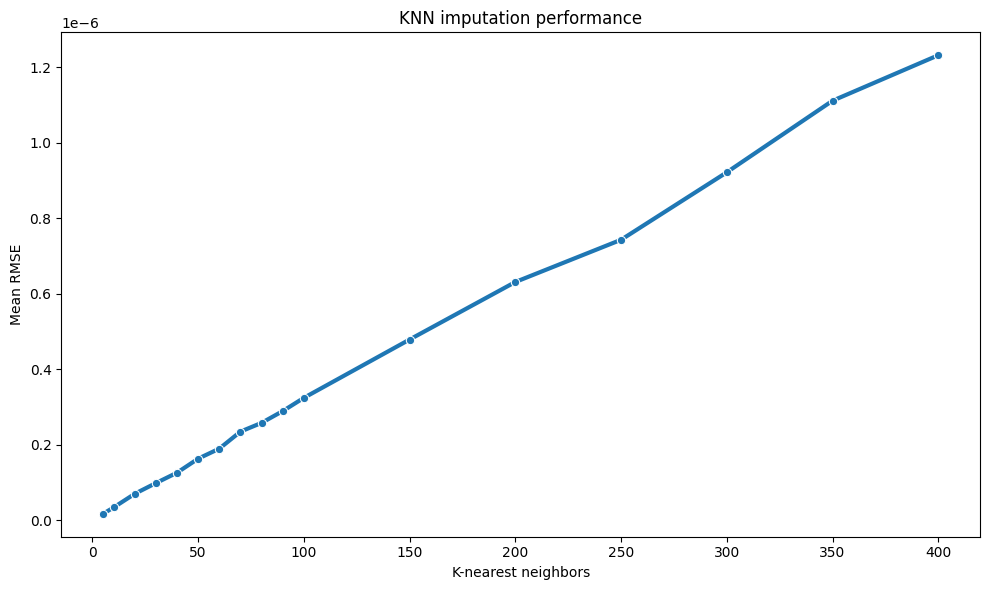

In [45]:
# show the results in a line plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=results_df,
    x="k",
    y="mean_rmse",
    marker="o",
    linewidth=3
)

plt.xlabel("K-nearest neighbors")
plt.ylabel("Mean RMSE")
plt.title("KNN imputation performance")

plt.tight_layout()
plt.show()

In [46]:
# Find the best K value based on the lowest mean RMSE
best_k = results_df.loc[results_df["mean_rmse"].idxmin(), "k"]
print("Best k:", best_k)

Best k: 5


In [47]:
# Impute the missing values in X using the best KNN imputer
imputer = KNNImputer(
    n_neighbors=5,
    weights="distance",
    metric="nan_euclidean"
)

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [ ]:
# Standardize the imputed FA data

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

In [ ]:
# Verifier l,allignement des index entre X_scaled et Y
(X_scaled.index == Y.index).all()

True

In [ ]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
cca = CCA(n_components=3)
X_c, Y_c = cca.fit_transform(X_scaled, Y)

In [ ]:
# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

Dimension canonique 1 : r = 0.479
Dimension canonique 2 : r = 0.398
Dimension canonique 3 : r = 0.262


In [ ]:
# Voir le poids des faisceaux
brain_weights = pd.DataFrame(
    cca.x_weights_,
    index=X.columns,
    columns=[f"CCA{i+1}" for i in range(cca.x_weights_.shape[1])]
)

brain_weights.sort_values("CCA1", key=lambda s: abs(s), ascending=False).head(15)

,CCA1,CCA2,CCA3
bundle,,,
CG_R,0.429957,-0.117115,-0.359999
CG_R_An,-0.327235,0.179838,0.262158
OR_ML_R,-0.271155,0.077264,-0.056967
UF_L,0.248615,0.242302,0.027800
AF_R,-0.228394,0.003194,-0.068355
CG_L_An,0.224623,0.040908,-0.025666
PYT_L,0.198484,0.094945,0.596090
CC_Pr_Po,0.197935,-0.143463,0.023405
FPT_L,-0.188639,-0.022308,-0.042911


In [ ]:
# Voir le poids des variables cognitives
cog_weights = pd.DataFrame(
    cca.y_weights_,
    index=Y.columns,
    columns=[f"CCA{i+1}" for i in range(cca.y_weights_.shape[1])]
)

cog_weights.sort_values("CCA1", key=lambda s: abs(s), ascending=False)

,CCA1,CCA2,CCA3
MEM,0.704175,-0.429877,-0.565105
EFPS,0.543935,0.838164,0.040202
VA,0.456369,-0.335690,0.824039


In [ ]:
# Calculer les loadings des faisceaux pour la première dimension canonique 
brain_scores_1 = X_c[:, 0]

brain_loadings_1 = pd.Series(
    [np.corrcoef(X_scaled.iloc[:, j], brain_scores_1)[0, 1] for j in range(X_scaled.shape[1])],
    index=X_scaled.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

brain_loadings_1.head(15)

bundle
CC_Pr_Po            0.405443
CG_R                0.404714
CC_Oc               0.398617
SLF_L               0.375731
CG_L_An             0.372377
ILF_L               0.367112
CG_R_An             0.361411
CG_L                0.347518
CC_Pa               0.339848
FAT_L               0.337079
AF_L                0.330889
IFOF_L              0.330629
POPT_L              0.316768
MdLF_R              0.316023
POPT_L_Brainstem    0.310151
Name: loading_CCA1, dtype: float64

In [ ]:
#   Calculer les loadings des variables cognitives pour la première dimension canonique
cog_scores_1 = Y_c[:, 0]

cog_loadings_1 = pd.Series(
    [np.corrcoef(Y.iloc[:, j], cog_scores_1)[0, 1] for j in range(Y.shape[1])],
    index=Y.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

cog_loadings_1

MEM     0.925628
VA      0.858418
EFPS    0.788657
Name: loading_CCA1, dtype: float64

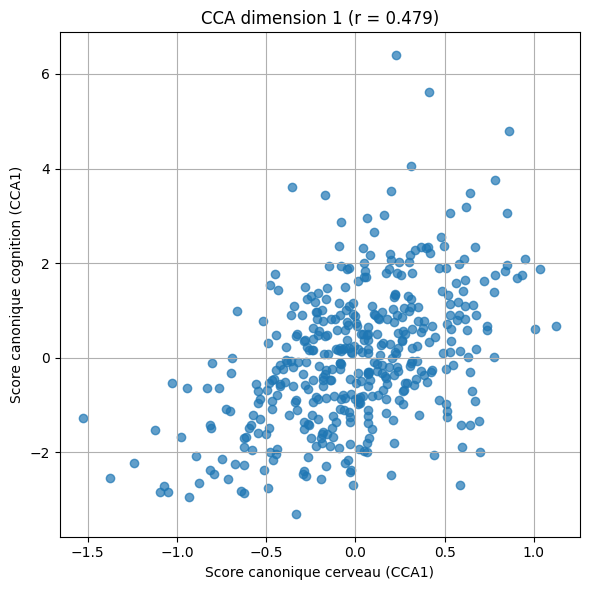

In [ ]:
# Visualiser les scores canoniques pour la première dimension
plt.figure(figsize=(6, 6))
plt.scatter(X_c[:, 0], Y_c[:, 0], alpha=0.7)
plt.xlabel("Score canonique cerveau (CCA1)")
plt.ylabel("Score canonique cognition (CCA1)")
plt.title(f"CCA dimension 1 (r = {canonical_corrs[0]:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()